**AG News**

In [37]:
import pandas as pd
import re
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

Loading Datasets and Initial View of Data

In [89]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [90]:
train_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [91]:
test_df.head()

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


Split of Data for Training and Testing

In [92]:
X_train = train_df['Description']
X_test = test_df['Description']
y_train = train_df['Class Index']
y_test = test_df['Class Index']

In [93]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (120000,), y_train shape: (120000,)
X_test shape: (7600,), y_test shape: (7600,)


Cleaning of Grammar

In [94]:
stopwords = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", 
    "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 
    'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 
    'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 
    'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 
    'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 
    'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'through', 'during', 
    'before', 'after', 'above', 'below', 'up', 'down', 'in', 'out', 'on', 'off', 
    'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 
    'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 
    'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 
    'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', "don't", 
    'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 
    'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 
    'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 
    'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 
    'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 
    'wouldn', "wouldn't"
}

In [95]:
def processWords(word):
    word = re.sub(r'http\S+|www\S+', '', word)
    word = re.sub(r'[^a-zA-Z0-9\s]', '', word)
    word = word.lower()
    word = re.sub(r'\s+', ' ', word).strip()

    words = word.split()
    words = [w for w in words if w not in stopwords]

    return ' '.join(words)

In [96]:
X_train = X_train.apply(processWords)
X_test = X_test.apply(processWords)

In [97]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (120000,), y_train shape: (120000,)
X_test shape: (7600,), y_test shape: (7600,)


In [98]:
print(X_train.head())

0    reuters shortsellers wall streets dwindlingban...
1    reuters private investment firm carlyle groupw...
2    reuters soaring crude prices plus worriesabout...
3    reuters authorities halted oil exportflows fro...
4    afp tearaway world oil prices toppling records...
Name: Description, dtype: object


In [99]:
print(X_test.head())

0    unions representing workers turner newall say ...
1    spacecom toronto canada secondteam rocketeers ...
2    ap company founded chemistry researcher univer...
3    ap barely dawn mike fitzpatrick starts shift b...
4    ap southern californias smogfighting agency we...
Name: Description, dtype: object


Manual Implementation

In [100]:
class BagOfWords:
    def __init__(self):
        self.vocab = {}
    
    def fit(self, data, max_vocab=100000):
        freq = {}
        for line in data:
            for w in line.split():
                freq[w] = freq.get(w, 0) + 1
        top_words = sorted(freq.items(), key=lambda x: -x[1])[:max_vocab]
        self.vocab = {w: i for i, (w, _) in enumerate(top_words)}
        self.vocab_size = len(self.vocab)
    
    def vectorize_counts(self, line):
        vec = np.zeros(self.vocab_size, dtype=float)
        for w in line.split():
            if w in self.vocab:
                vec[self.vocab[w]] += 1
        return vec

In [101]:
bow = BagOfWords()
bow.vocab = {"the":0, "cat":1, "sat":2, "on":3, "mat":4}
bow.vocab_size = len(bow.vocab)
print(bow.vectorize_counts("the cat sat on the mat"))


[2. 1. 1. 1. 1.]


In [102]:
bow = BagOfWords()
bow.fit(X_train, max_vocab=7000)


In [103]:
X_train_vec = np.array([bow.vectorize_counts(s) for s in X_train], dtype=np.float32)
X_test_vec = np.array([bow.vectorize_counts(s) for s in X_test], dtype=np.float32)

In [104]:
class NaiveBayes:
    def __init__(self, vocab_size):
        self.class_count = {}
        self.word_count = {}
        self.vocab_size = vocab_size
        self.class_prior = {}
        self.word_prob = {}

    def train(self, X_text, y, bow):
        for i in range(len(y)):
            c = y.iloc[i]
            if c not in self.class_count:
                self.class_count[c] = 0
                self.word_count[c] = np.zeros(self.vocab_size, dtype=float)
            self.class_count[c] += 1
            vec = bow.vectorize_counts(X_text.iloc[i])
            self.word_count[c] += vec

        total_samples = len(y)
        for c in self.class_count:
            self.class_prior[c] = np.log(self.class_count[c] / total_samples)
            self.word_prob[c] = np.log(
                (self.word_count[c] + 1) / (np.sum(self.word_count[c]) + self.vocab_size)
            )

    def predict(self, X_text, bow):
        preds = []
        for i in range(len(X_text)):
            vec = bow.vectorize_counts(X_text.iloc[i])
            scores = {c: self.class_prior[c] + np.sum(vec * self.word_prob[c])
                      for c in self.class_prior}
            preds.append(max(scores, key=scores.get))
        return preds


Accuracy: 0.8810526315789474
Precision: 0.8804460932570417
Recall: 0.8810526315789474
F1 Score: 0.8805788999790979
[[1679   74   89   58]
 [  36 1839   11   14]
 [  85   22 1561  232]
 [  85   34  164 1617]]


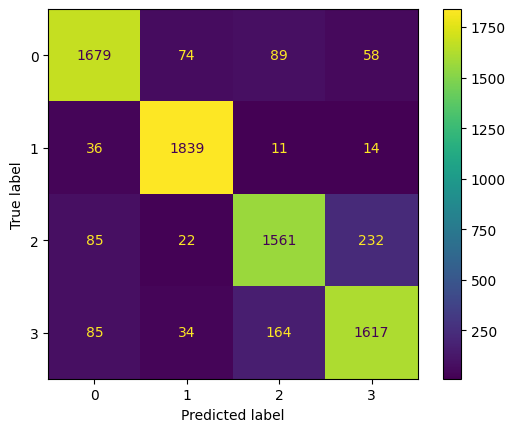

In [105]:
nb = NaiveBayes(vocab_size=len(bow.vocab))
nb.train(X_train, y_train, bow)
y_pred = nb.predict(X_test, bow)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))
print(confusion_matrix(y_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

Calling from Library

In [106]:
from sklearn.naive_bayes import MultinomialNB
sk_nb=MultinomialNB()

In [107]:
sk_nb.fit(X_train_vec, y_train)

MultinomialNB()

In [108]:
y_predicted = sk_nb.predict(X_test_vec)

Accuracy: 0.8810526315789474
Precision: 0.8804446769254854
Recall: 0.8810526315789474
F1 Score: 0.880574324088868
[[1679   74   89   58]
 [  36 1839   11   14]
 [  85   22 1561  232]
 [  87   34  162 1617]]


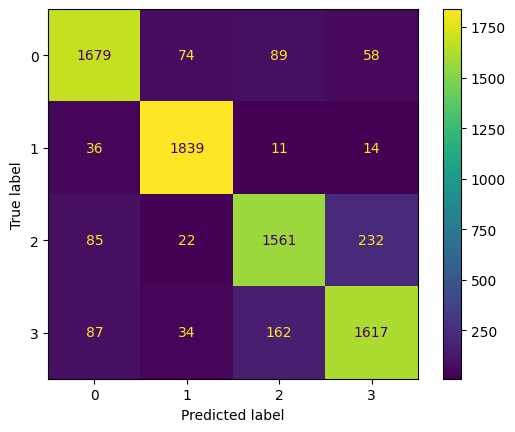

In [109]:
print("Accuracy:", accuracy_score(y_test, y_predicted))
print("Precision:", precision_score(y_test, y_predicted, average='macro'))
print("Recall:", recall_score(y_test, y_predicted, average='macro'))
print("F1 Score:", f1_score(y_test, y_predicted, average='macro'))
print(confusion_matrix(y_test, y_predicted))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_predicted)).plot()

Comparison

In [110]:
print("Manual Muntinomial NB Accuracy  :", accuracy_score(y_test, y_pred))
print("Sklearn Multinomial NB Accuracy :", accuracy_score(y_test, y_predicted))

Manual Muntinomial NB Accuracy  : 0.8810526315789474
Sklearn Multinomial NB Accuracy : 0.8810526315789474


Why Multinomial

For the AG-News Dataset, Multinomial Naive Bayes is the better choice.
This dataset contains text news descriptions where word frequency is meaningful. Multinomial Naive Bayes models word counts, making it ideal for text classification. It considers how often words appear (e.g., "economy" appears frequently in business articles but rarely in sports), which provides valuable information for distinguishing between news categories like Business, Sports, and Technology.

Observation

For the AG News dataset, a four-class classification problem, your manual MultinomialNB and sklearn’s implementation produced almost identical results. Both achieved an accuracy of 88.1%, precision around 88.0%, recall of 88.1%, and an F1 score of 88.1%. The confusion matrices are nearly the same, with only minor differences in a few counts. This demonstrates that your manual MultinomialNB captures the essential probability computations correctly and performs just as well as sklearn’s optimized version.